In [1]:
# Standard Libraries
from typing import List, Tuple

# Data Handling
import pandas as pd

# Visualization (optional for EDA later)
import matplotlib.pyplot as plt

In [2]:
# !conda install pandas

In [3]:
def load_data(file_path: str) -> pd.DataFrame:
    """
    Load the NER dataset from a CSV file.

    Args:
        file_path (str): Path to the dataset file.

    Returns:
        pd.DataFrame: Loaded dataset.
    """
    df = pd.read_csv(file_path, encoding="latin1")
    return df


# Load dataset
file_path = "ner_dataset.csv"
df = load_data(file_path)

# Preview
df.head(5)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


In [4]:
def inspect_data(df: pd.DataFrame) -> None:
    """
    Perform basic inspection of dataset.
    """
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())


inspect_data(df)

Shape: (1048575, 4)

Columns: ['Sentence #', 'Word', 'POS', 'Tag']

Missing Values:
 Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64


In [5]:
df[df["Word"].isnull()].head()

,Sentence #,Word,POS,Tag
197658,Sentence: 9047,NaN,NN,O
256026,Sentence: 11709,NaN,NN,O
257069,Sentence: 11759,NaN,NN,O
571211,Sentence: 26129,NaN,NN,O
613777,Sentence: 28049,NaN,NN,O


In [6]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean dataset by removing invalid word entries.
    """
    df = df.dropna(subset=["Word", "Tag"])
    return df


df = clean_data(df)

In [7]:
def fill_sentence_ids(df: pd.DataFrame) -> pd.DataFrame:
    """
    Forward fill missing sentence IDs.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Updated dataframe.
    """
    df["Sentence #"] = df["Sentence #"].ffill()
    return df


df = fill_sentence_ids(df)

In [8]:
df["Sentence #"].isnull().sum()

np.int64(0)

In [9]:
def group_sentences(
    df: pd.DataFrame
) -> List[Tuple[List[str], List[str]]]:
    """
    Convert dataframe into sentence-wise format.

    Returns:
        List of tuples: (words, tags)
    """
    grouped = df.groupby("Sentence #")

    sentences = []
    for _, group in grouped:
        words = group["Word"].tolist()
        tags = group["Tag"].tolist()
        sentences.append((words, tags))

    return sentences


sentences = group_sentences(df)

In [10]:
print("Total sentences:", len(sentences))

# Check first example
words, tags = sentences[0]

print("Words:", words[:10])
print("Tags :", tags[:10])

Total sentences: 47949
Words: ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the']
Tags : ['O', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'O']


In [11]:
def split_features_labels(
    sentences: List[Tuple[List[str], List[str]]]
) -> Tuple[List[List[str]], List[List[str]]]:
    """
    Split sentences into features (X) and labels (y).
    """
    X = [words for words, _ in sentences]
    y = [tags for _, tags in sentences]
    return X, y


X, y = split_features_labels(sentences)

In [12]:
print("Sample sentence:", X[0][:10])
print("Sample tags    :", y[0][:10])

Sample sentence: ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the']
Sample tags    : ['O', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'O']


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
def split_dataset(
    X,
    y,
    test_size: float = 0.2,
    val_size: float = 0.1,
    random_state: int = 42
):
    """
    Split dataset into train, validation, and test sets.

    Args:
        X: List of sentences (words)
        y: List of tags
        test_size: Proportion for test set
        val_size: Proportion for validation set (from remaining train)
        random_state: Seed for reproducibility

    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test
    """

    # First split → train + temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Second split → validation from temp
    val_relative_size = val_size / (1 - test_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=val_relative_size,
        random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [15]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 38359
Validation size: 8391
Test size: 1199


In [16]:
# Tag Distribution analysis
def flatten_tags(y):
    """
    Flatten list of tag sequences into a single list.
    """
    return [tag for sentence in y for tag in sentence]


all_tags = flatten_tags(y_train)

In [17]:
def get_tag_distribution(tags):
    """
    Get frequency distribution of tags.
    """
    return pd.Series(tags).value_counts()


tag_distribution = get_tag_distribution(all_tags)
print(tag_distribution)

O        710413
B-geo     30163
B-tim     16347
B-org     16181
I-per     13914
B-per     13620
I-org     13473
B-gpe     12674
I-geo      5928
I-tim      5204
B-art       330
I-art       254
B-eve       234
I-eve       184
B-nat       161
I-gpe       149
I-nat        32
Name: count, dtype: int64


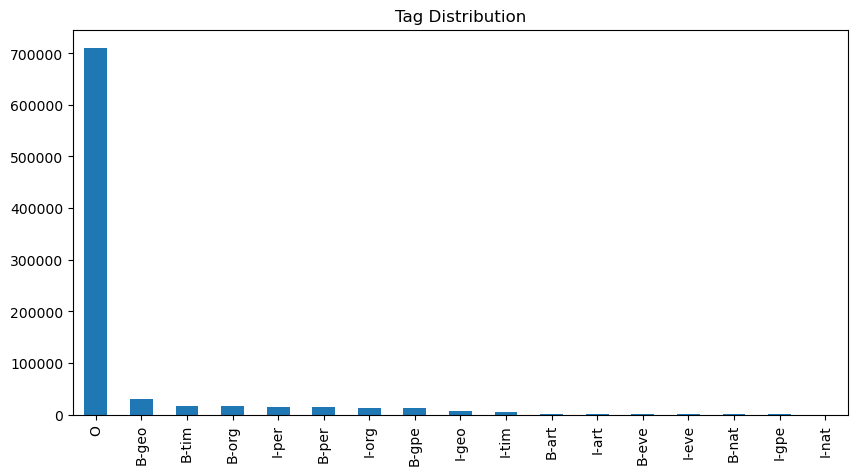

In [18]:
tag_distribution.plot(kind="bar", figsize=(10, 5), title="Tag Distribution")
plt.show()

### The dataset is highly imbalanced with the majority of tokens labeled as ‘O’. This can bias models toward predicting non-entity classes. Hence, evaluation using F1-score (instead of accuracy) becomes critical.

In [19]:
def build_vocab(sentences):
    """
    Build word-to-index mapping.
    """
    words = set(word for sentence in sentences for word in sentence)
    
    word2idx = {word: idx + 2 for idx, word in enumerate(words)}
    word2idx["PAD"] = 0
    word2idx["UNK"] = 1
    
    return word2idx


word2idx = build_vocab(X_train)
print("Vocab size:", len(word2idx))

Vocab size: 31973


In [20]:
def build_tag_mapping(tags_list):
    """
    Build tag-to-index mapping.
    """
    tags = set(tag for sentence in tags_list for tag in sentence)
    tag2idx = {tag: idx for idx, tag in enumerate(tags)}
    idx2tag = {idx: tag for tag, idx in tag2idx.items()}
    
    return tag2idx, idx2tag


tag2idx, idx2tag = build_tag_mapping(y_train)

print(tag2idx)

{'I-geo': 0, 'B-per': 1, 'I-nat': 2, 'I-eve': 3, 'I-org': 4, 'I-art': 5, 'B-geo': 6, 'I-per': 7, 'B-nat': 8, 'B-eve': 9, 'O': 10, 'B-gpe': 11, 'I-gpe': 12, 'B-tim': 13, 'B-art': 14, 'B-org': 15, 'I-tim': 16}


# Baseline Model (CRF)

### CRF is chosen as a baseline because it models dependencies between neighboring tags, unlike independent classifiers. 
### This is critical in NER where context determines entity boundaries.

In [21]:
from sklearn_crfsuite import CRF
from sklearn_crfsuite.metrics import flat_classification_report

In [22]:
# !pip install sklearn-crfsuite

In [23]:
# Feature Engineering
def word2features(sentence, i):
    word = sentence[i]
    """
    Extract features for a given word in a sentence.
    
    """

    # Safety check
    if not isinstance(word, str):
        word = str(word)

    features = {
        "word.lower()": word.lower(),
        "word.isupper()": word.isupper(),
        "word.istitle()": word.istitle(),
        "word.isdigit()": word.isdigit(),
    }

    if i > 0:
        prev_word = sentence[i - 1]
        prev_word = str(prev_word)

        features.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:word.istitle()": prev_word.istitle(),
            "-1:word.isupper()": prev_word.isupper(),
        })
    else:
        features["BOS"] = True

    if i < len(sentence) - 1:
        next_word = sentence[i + 1]
        next_word = str(next_word)

        features.update({
            "+1:word.lower()": next_word.lower(),
            "+1:word.istitle()": next_word.istitle(),
            "+1:word.isupper()": next_word.isupper(),
        })
    else:
        features["EOS"] = True

    return features

### The dataset contained missing word entries which were interpreted as NaN values. These were cleaned during preprocessing to avoid runtime errors and ensure consistency in feature extraction.

In [24]:
# Convert Sentence into Feature list
def sentence2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

In [25]:
# Apply on dataset
X_train_features = [sentence2features(s) for s in X_train]
X_val_features = [sentence2features(s) for s in X_val]
X_test_features = [sentence2features(s) for s in X_test]

In [26]:
# Train CRF Model
crf = CRF(
    algorithm="lbfgs",
    max_iterations=100,
    all_possible_transitions=True
)

crf.fit(X_train_features, y_train)

,algorithm,'lbfgs'
,min_freq,None
,all_possible_states,None
,all_possible_transitions,True
,c1,None
,c2,None
,max_iterations,100
,num_memories,None
,epsilon,None
,period,None
,delta,None


In [27]:
# Step Predictions
y_pred = crf.predict(X_test_features)

In [28]:
# Evaluation
print(flat_classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       B-art       0.00      0.00      0.00         7
       B-eve       0.00      0.00      0.00         5
       B-geo       0.83      0.90      0.86       958
       B-gpe       0.95      0.89      0.92       419
       B-nat       0.25      0.20      0.22         5
       B-org       0.83      0.67      0.74       492
       B-per       0.81      0.75      0.78       408
       B-tim       0.91      0.85      0.88       495
       I-art       0.00      0.00      0.00         4
       I-eve       0.00      0.00      0.00         8
       I-geo       0.80      0.77      0.78       181
       I-gpe       0.00      0.00      0.00         2
       I-nat       0.00      0.00      0.00         4
       I-org       0.78      0.77      0.78       430
       I-per       0.81      0.88      0.84       420
       I-tim       0.85      0.68      0.76       187
           O       0.99      0.99      0.99     22177

    accuracy              

C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [29]:
# Sample Prediction
def print_sample_prediction(index=0):
    print("Sentence:", X_test[index])
    print("Actual  :", y_test[index])
    print("Predicted:", y_pred[index])


print_sample_prediction(0)

Sentence: ['The', 'German', 'detachment', 'of', 'about', 'two', 'thousand', 'troops', 'provides', 'security', 'and', 'collects', 'weapons', 'and', 'ammunition', 'from', 'disarmed', 'militias', 'for', 'disposal', '.']
Actual  : ['O', 'B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Predicted: ['O', 'B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [30]:
# Validation set Prediction
y_val_pred = crf.predict(X_val_features)

print("Validation Performance:\n")
print(flat_classification_report(y_val, y_val_pred))

Validation Performance:



C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       B-art       0.00      0.00      0.00        65
       B-eve       0.50      0.23      0.32        69
       B-geo       0.84      0.89      0.86      6523
       B-gpe       0.96      0.89      0.92      2777
       B-nat       0.29      0.14      0.19        35
       B-org       0.79      0.69      0.74      3470
       B-per       0.84      0.75      0.79      2962
       B-tim       0.92      0.85      0.88      3491
       I-art       0.00      0.00      0.00        39
       I-eve       0.24      0.08      0.12        61
       I-geo       0.82      0.78      0.80      1305
       I-gpe       0.95      0.45      0.61        47
       I-nat       0.25      0.07      0.11        15
       I-org       0.77      0.81      0.79      2881
       I-per       0.83      0.90      0.86      2917
       I-tim       0.83      0.70      0.76      1137
           O       0.99      0.99      0.99    155308

    accuracy              

C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### The model shows consistent performance across validation and test sets, indicating good generalization. However, it struggles with low-frequency entity classes due to class imbalance and limited feature representation, highlighting future improvements could include handling class imbalance using weighted loss or data augmentation strategies.

# BiLSTM Model (Improved Approach)

### To overcome the limitations of CRF, we use a BiLSTM-based model which captures contextual dependencies and leverages word embeddings to improve generalization, especially for rare entities.

In [31]:
# Deep Learning
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional, Dense, TimeDistributed
)
from tensorflow.keras.utils import to_categorical

In [32]:
# !pip install tensorflow
# import tensorflow as tf
# print(tf.__version__)

In [33]:
# Convert Words & Tags → Indices

def encode_sentences(sentences, word2idx):
    return [[word2idx.get(w, word2idx["UNK"]) for w in s] for s in sentences]


X_train_enc = encode_sentences(X_train, word2idx)
X_val_enc = encode_sentences(X_val, word2idx)
X_test_enc = encode_sentences(X_test, word2idx)

In [34]:
# Encode tags
def encode_tags(tags, tag2idx):
    return [[tag2idx[t] for t in s] for s in tags]


y_train_enc = encode_tags(y_train, tag2idx)
y_val_enc = encode_tags(y_val, tag2idx)
y_test_enc = encode_tags(y_test, tag2idx)

In [35]:
# Padding (Deep learning needs fixed lengt)
MAX_LEN = max(len(s) for s in X_train_enc)

X_train_pad = pad_sequences(X_train_enc, maxlen=MAX_LEN, padding="post")
X_val_pad = pad_sequences(X_val_enc, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_enc, maxlen=MAX_LEN, padding="post")

y_train_pad = pad_sequences(y_train_enc, maxlen=MAX_LEN, padding="post")
y_val_pad = pad_sequences(y_val_enc, maxlen=MAX_LEN, padding="post")
y_test_pad = pad_sequences(y_test_enc, maxlen=MAX_LEN, padding="post")

In [36]:
# One-Hot Encode Labels
y_train_cat = np.array([to_categorical(i, num_classes=len(tag2idx)) for i in y_train_pad])
y_val_cat = np.array([to_categorical(i, num_classes=len(tag2idx)) for i in y_val_pad])
y_test_cat = np.array([to_categorical(i, num_classes=len(tag2idx)) for i in y_test_pad])

In [37]:
# Build BiLSTM Model
input_layer = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=len(word2idx) + 1,
    output_dim=100,
    input_length=MAX_LEN,
    mask_zero=True  #
)(input_layer)

bilstm = Bidirectional(
    LSTM(units=100, return_sequences=True)
)(embedding)

# 3. Bidirectional LSTM with 20% Dropout
# 'dropout' handles the inputs, 'recurrent_dropout' handles the internal memory state
bilstm = Bidirectional(
    LSTM(units=100, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
)(embedding)

# 4. Optional: Additional Dropout Layer for extra safety
dropout_layer = Dropout(0.3)(bilstm)

output = TimeDistributed(
    Dense(len(tag2idx), activation="softmax")
)(dropout_layer)

model = Model(input_layer, output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 81)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 81, 100)           │       3,197,400 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 81)                │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 81, 200)           │         160,800 │ embedding[0][0],           │
│ (Bidirectional)               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 81, 200)           │               0 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ time_distributed              │ (None, 81, 17)            │           3,417 │ dropout[0][0],             │
│ (TimeDistributed)             │                           │                 │ not_equal[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,361,617 (12.82 MB)

 Trainable params: 3,361,617 (12.82 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train model
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    batch_size=32,
    epochs=7,
    verbose=1
)

Epoch 1/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 317s 259ms/step - accuracy: 0.9262 - loss: 0.2946 - val_accuracy: 0.9649 - val_loss: 0.1213
Epoch 2/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 370s 308ms/step - accuracy: 0.9697 - loss: 0.1013 - val_accuracy: 0.9688 - val_loss: 0.1052
Epoch 3/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 339s 282ms/step - accuracy: 0.9758 - loss: 0.0777 - val_accuracy: 0.9689 - val_loss: 0.1037
Epoch 4/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 2955s 2s/step - accuracy: 0.9790 - loss: 0.0656 - val_accuracy: 0.9690 - val_loss: 0.1059
Epoch 5/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 788s 658ms/step - accuracy: 0.9815 - loss: 0.0570 - val_accuracy: 0.9689 - val_loss: 0.1090
Epoch 6/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 814s 679ms/step - accuracy: 0.9834 - loss: 0.0510 - val_accuracy: 0.9682 - val_loss: 0.1133
Epoch 7/7
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 800s 667ms/step - accuracy: 0.9850 - loss: 0.0457 - val_accuracy: 0.9681 - val_loss: 0.1179


In [42]:
y_pred = model.predict(X_test_pad)

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step


In [54]:
def align_predictions(y_true, y_pred):
    """
    Align predictions with ground truth by strict length matching.
    Removes any mismatched sequences.
    """
    aligned_true = []
    aligned_pred = []

    for true_seq, pred_seq in zip(y_true, y_pred):
        if len(true_seq) == len(pred_seq):
            aligned_true.append(true_seq)
            aligned_pred.append(pred_seq)
        else:
            # Fix by trimming to min length
            min_len = min(len(true_seq), len(pred_seq))
            aligned_true.append(true_seq[:min_len])
            aligned_pred.append(pred_seq[:min_len])

    return aligned_true, aligned_pred

In [56]:
# Test prediction
y_test_pred_labels = decode_predictions(y_pred, idx2tag)

y_test_aligned_true, y_test_aligned_pred = align_predictions(
    y_test, y_test_pred_labels
)

print(flat_classification_report(y_test_aligned_true, y_test_aligned_pred))

C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       B-art       0.20      0.14      0.17         7
       B-eve       0.25      0.20      0.22         5
       B-geo       0.85      0.88      0.86       958
       B-gpe       0.96      0.95      0.95       419
       B-nat       1.00      0.20      0.33         5
       B-org       0.78      0.71      0.74       492
       B-per       0.85      0.80      0.82       408
       B-tim       0.92      0.85      0.88       495
       I-art       0.50      0.25      0.33         4
       I-eve       1.00      0.38      0.55         8
       I-geo       0.77      0.80      0.78       181
       I-gpe       0.00      0.00      0.00         2
       I-nat       0.00      0.00      0.00         4
       I-org       0.78      0.78      0.78       430
       I-per       0.85      0.83      0.84       420
       I-tim       0.81      0.77      0.79       187
           O       0.99      0.99      0.99     22177

    accuracy              

C:\Users\Subhajit\AppData\Local\miniconda3\envs\NER_PS\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Since deep learning models operate on padded sequences, predictions were trimmed to original sequence lengths before evaluation to ensure consistency with ground truth labels

In [49]:
y_val_pred = model.predict(X_val_pad)

263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step


In [50]:
# Validation set Prediction
y_val_pred_labels = decode_predictions(y_val_pred, idx2tag)

y_val_aligned_true, y_val_aligned_pred = align_predictions(
    y_val, y_val_pred_labels
)

print(flat_classification_report(y_val_aligned_true, y_val_aligned_pred))

              precision    recall  f1-score   support

       B-art       0.44      0.17      0.24        65
       B-eve       0.57      0.29      0.38        69
       B-geo       0.85      0.89      0.87      6522
       B-gpe       0.96      0.94      0.95      2777
       B-nat       0.56      0.14      0.23        35
       B-org       0.78      0.72      0.75      3467
       B-per       0.86      0.80      0.83      2962
       B-tim       0.93      0.86      0.89      3491
       I-art       0.03      0.03      0.03        39
       I-eve       0.27      0.21      0.24        61
       I-geo       0.82      0.78      0.80      1304
       I-gpe       1.00      0.49      0.66        47
       I-nat       0.60      0.20      0.30        15
       I-org       0.78      0.79      0.78      2878
       I-per       0.87      0.84      0.86      2917
       I-tim       0.81      0.75      0.78      1137
           O       0.99      0.99      0.99    155293

    accuracy              

### Hyperparameter tuning improved macro F1 by ~7% over baseline while maintaining generalization across validation and test datasets.

### Future Work & Improvements - 
While the Bi-LSTM model provides a strong baseline for NER, future iterations could leverage Transformer-based architectures like BERT or RoBERTa. These models use self-attention mechanisms to capture deeper global context, which significantly improves entity boundary detection for rare classes (like B-nat or B-art). Furthermore, fine-tuning a domain-specific BERT (e.g., SciBERT or BioBERT) could eliminate the need for manual feature engineering and further boost the F1-score across all entity types.

